<a href="https://colab.research.google.com/github/ayaelsadek/restaurant-cv-demo/blob/main/demo_with_alerts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Download a public crowd/street video**

In [57]:
# Download sample video from GitHub
import urllib.request

url = "https://github.com/intel-iot-devkit/sample-videos/raw/master/person-bicycle-car-detection.mp4"

print("Downloading...")
urllib.request.urlretrieve(url, "test_video.mp4")

import os
size = os.path.getsize("test_video.mp4")
print(f"Downloaded: {size / 1024 / 1024:.1f} MB")

Downloading...
Downloaded: 5.8 MB


Frame shape: (432, 768, 3)


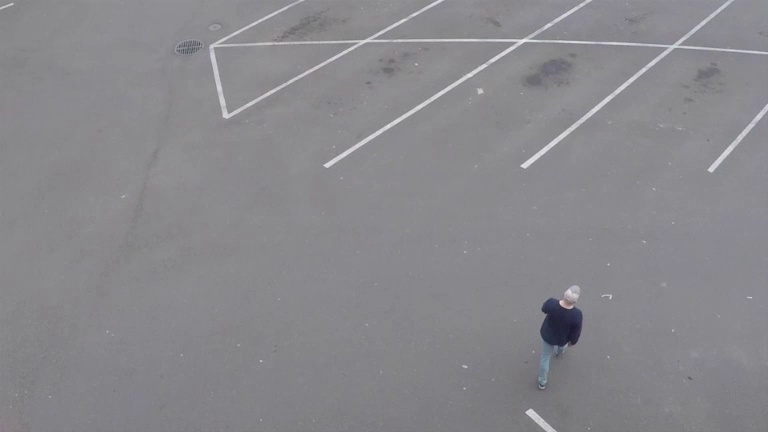

In [58]:
import cv2
from IPython.display import display, Image

cap = cv2.VideoCapture("test_video.mp4")
cap.set(cv2.CAP_PROP_POS_FRAMES, 30)
ret, frame = cap.read()
cap.release()

print("Frame shape:", frame.shape if ret else "Failed")
_, buffer = cv2.imencode('.jpg', frame)
display(Image(data=buffer.tobytes()))

In [79]:
from re import VERBOSE
from ast import mod
from ultralytics import YOLO
import cv2
from IPython.display import display, Image
import ipywidgets as widgets
import datetime

# Load the YOLOv8 model
model = YOLO('yolov8n.pt')

#open video
cap=cv2.VideoCapture('test_video.mp4')

width=int(cap.get(3))
height=int(cap.get(4))
fps=int(cap.get(cv2.CAP_PROP_FPS))
print(f"Video : {width}x{height} @ {fps}fps")

#output video writer
fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter('output_video.avi', fourcc,
                     fps, (width, height))

#event config
crowd_threshold=1
cooldown_frames=30
last_alart_frame=-cooldown_frames
event_log=[]

print("VideoWriter opened:", out.isOpened())

frame_count=0
max=frames=400

while cap.isOpened() and frame_count<max:
    # Read a frame from the video
    ret, frame=cap.read()
    if not ret:
      break

    #Run inference
    results=model(frame, verbose=False, conf=0.5, iou=0.5)

    #Count people
    people=[box for box in results[0].boxes if int(box.cls)==0]
    count=len(people)

    #Event detection
    if count > crowd_threshold and (frame_count - last_alart_frame) > cooldown_frames:
     timestamp = datetime.datetime.now().isoformat()
     event= {
         'event':'crowding_detected',
         'people_count':count,
         'timestamp':timestamp,
         'frame':frame_count,
         'branch_id':'branch_cairo_01'
     }
     event_log.append(event)
     last_alart_frame=frame_count
     print(f"🚨 ALERT at {timestamp} — {count} people detected")


    #Visualize
    annotated_frame=results[0].plot()
    #people count
    cv2.putText(annotated_frame, f'people detected: {count}', (20, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3)
    #alert indicator
    if count > crowd_threshold:
      cv2.putText(annotated_frame, "!! CROWDING ALERT", (20, 100),
                  cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 3)

    out.write(annotated_frame)
    frame_count+=1
    if frame_count %50==0:
      print(f"Processed {frame_count} frames")

cap.release()
out.release()
print('Done output saved to output.avi')

Video : 768x432 @ 12fps
VideoWriter opened: True
Processed 50 frames
Processed 100 frames
Processed 150 frames
Processed 200 frames
Processed 250 frames
Processed 300 frames
Processed 350 frames
Processed 400 frames
Done output saved to output.avi


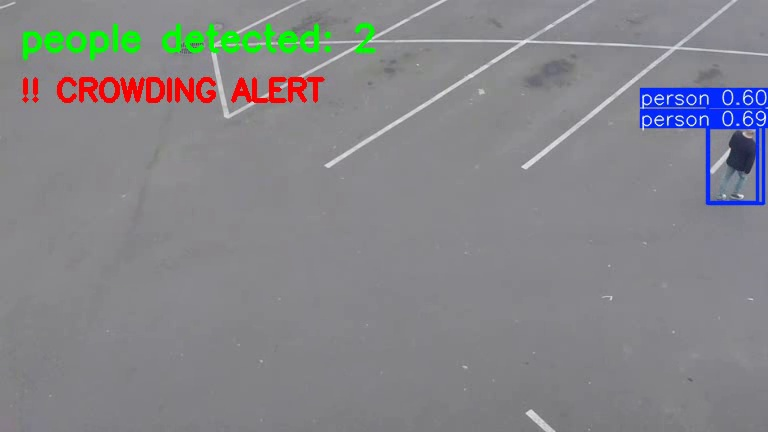

In [78]:
alert_frame = event_log[0]['frame']  # first alert frame number

cap = cv2.VideoCapture("output_video.avi")
cap.set(cv2.CAP_PROP_POS_FRAMES, alert_frame)
ret, frame = cap.read()
cap.release()

_, buffer = cv2.imencode('.jpg', frame)
display(Image(data=buffer.tobytes()))

In [73]:

# --- Print event summary ---
print(f"\n✅ Done — {frame_count} frames processed")
print(f"📋 Total events logged: {len(event_log)}")
for e in event_log:
    print(f"   [{e['timestamp']}] frame {e['frame']} — {e['people_count']} people at {e['branch_id']}")



✅ Done — 400 frames processed
📋 Total events logged: 1
   [2026-05-01T06:59:07.840027] frame 76 — 2 people at branch_cairo_01
